In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

'''#Run this to regenerate the .npy files for the data
df = pd.read_parquet("data/RMDC26_Beginner_Tier_test.parquet")
print(df.columns)
print(df.shape)

event_names = [f"RMDC26_{i:06d}" for i in range(1, 189)]

# event names are from RMDC26_000001 to RMDC26_000188
# filters are ['F087', 'F146', 'F213']

def makeFliterDataMatrix(filter, df):
  res = []
  filter_name = filter
  for event_id in event_names:
    res.append(df.loc[(df["name"] == event_id) & (df["filt"] == filter_name), ["mag","mag_err","bjd"]].sort_values("bjd").to_numpy().T)
  return np.array(res)

F087 = makeFliterDataMatrix("F087", df)
print(F087.shape)
F146 = makeFliterDataMatrix("F146", df)
print(F146.shape)
F213 = makeFliterDataMatrix("F213", df)
print(F146.shape)

np.save("data/F087.npy", F087)
np.save("data/F146.npy", F146)
np.save("data/F213.npy", F213)'''

F087 = np.load("data/F087.npy")
F146 = np.load("data/F146.npy")
F213 = np.load("data/F213.npy")

F087_mags = F146[:, 0, :]   # (n_events, n_points)
bjd = F146[0, 2, :]         # shared time axis

In [2]:
# Each event's light curve is observed in 6 separate campaigns, with large
# time gaps between them. bjd is a shared grid across all events, so the
# chunk boundaries are the same for every event.

def find_chunks(time_axis, gap_threshold=10.0):
    """Split a shared time axis into contiguous observing chunks, breaking
    wherever the gap between consecutive points exceeds gap_threshold (days)."""
    gaps = np.diff(time_axis)
    break_points = np.where(gaps > gap_threshold)[0]
    starts = np.concatenate(([0], break_points + 1))
    ends = np.concatenate((break_points, [len(time_axis) - 1]))
    return list(zip(starts.tolist(), ends.tolist()))

chunks = find_chunks(bjd)
print(f"Found {len(chunks)} chunks: {chunks}")

Found 6 chunks: [(0, 7699), (7700, 15400), (15401, 23103), (23104, 30804), (30805, 38506), (38507, 46207)]


In [3]:
def find_anomalies(series, chunks, threshold=3.0, tol=5):
    """
    Find sustained-deviation anomalies in a light curve.

    The noise baseline (mean, S.D.) is computed from the whole series --
    most of it is flat noise around this baseline, and the lensing event
    shows up as a sustained deviation away from it. Each chunk is scanned
    independently so an anomaly can never span the gap between chunks --
    it always closes by the last point of the chunk it started in, instead
    of running on into (or past) the next observing campaign.

    threshold : n, number of S.D. from the baseline mean that counts as
                "above threshold".
    tol       : d, a run must exceed this many consecutive points to
                start (or end) an anomaly.

    Returns a list of (start_idx, end_idx, chunk_idx) in global index
    coordinates.
    """
    mean = series.mean()
    std = series.std()

    anomalies = []
    for c_idx, (c_start, c_end) in enumerate(chunks):
        chunk_series = series[c_start:c_end + 1]
        dev = np.abs(chunk_series - mean) > threshold * std

        above_run = 0
        below_run = 0
        in_anomaly = False
        start_idx = None

        for t, flagged in enumerate(dev):
            if flagged:
                above_run += 1
                below_run = 0
                if not in_anomaly and above_run == tol + 1:
                    in_anomaly = True
                    start_idx = t - tol
            else:
                below_run += 1
                above_run = 0
                if in_anomaly and below_run == tol + 1:
                    end_idx = t - tol
                    anomalies.append((start_idx + c_start, end_idx + c_start, c_idx))
                    in_anomaly = False
                    start_idx = None

        # Chunk ended mid-anomaly: close it at the chunk's last point.
        if in_anomaly:
            anomalies.append((start_idx + c_start, c_end, c_idx))

    return anomalies

Event 1: found 1 anomaly window(s): [(25074, 26201, 3)]


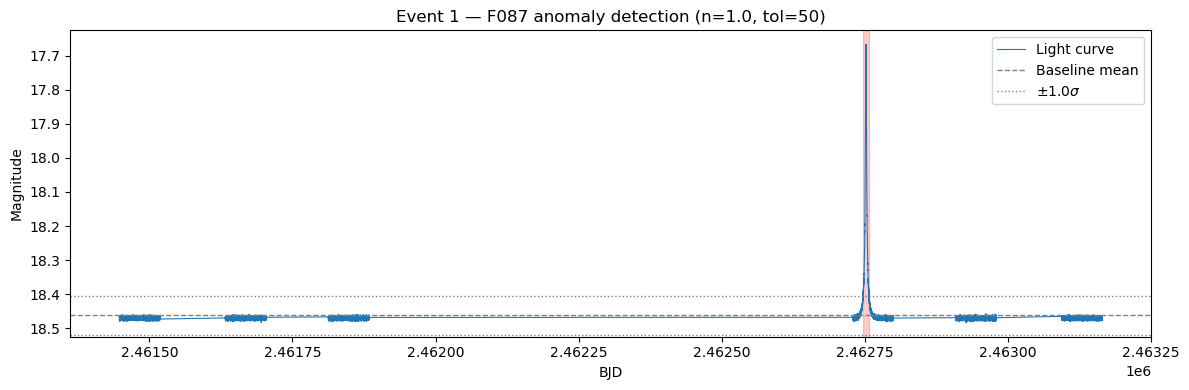

In [4]:
threshold_n = 1.0   # n S.D. from baseline
tol_d = 50            # d consecutive points

event_idx = 1
series = F087_mags[event_idx]
mean = series.mean()
std = series.std()

anomalies = find_anomalies(series, chunks, threshold=threshold_n, tol=tol_d)
print(f"Event {event_idx}: found {len(anomalies)} anomaly window(s): {anomalies}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bjd, series, linewidth=0.8, label="Light curve")
ax.axhline(mean, color="gray", linestyle="--", linewidth=1, label="Baseline mean")
ax.axhline(mean + threshold_n * std, color="gray", linestyle=":", linewidth=1)
ax.axhline(mean - threshold_n * std, color="gray", linestyle=":", linewidth=1, label=f"±{threshold_n}$\\sigma$")

for start, end, _ in anomalies:
    ax.axvspan(bjd[start], bjd[end], color="red", alpha=0.2)

ax.invert_yaxis()
ax.set_xlabel("BJD")
ax.set_ylabel("Magnitude")
ax.set_title(f"Event {event_idx} — F087 anomaly detection (n={threshold_n}, tol={tol_d})")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Run anomaly detection across every event, and save the detected windows
# (event, index range, BJD date range, and the enclosing chunk) to a table.

records = []
for i in range(F087_mags.shape[0]):
    for (start, end, c_idx) in find_anomalies(F087_mags[i], chunks, threshold=threshold_n, tol=tol_d):
        chunk_start, chunk_end = chunks[c_idx]
        records.append({
            "event_idx": i,
            "start_idx": start,
            "end_idx": end,
            "start_bjd": bjd[start],
            "end_bjd": bjd[end],
            "n_points": end - start + 1,
            "chunk_idx": c_idx,
            "chunk_start_idx": chunk_start,
            "chunk_end_idx": chunk_end,
            "chunk_start_bjd": bjd[chunk_start],
            "chunk_end_bjd": bjd[chunk_end],
        })

anomalies_df = pd.DataFrame(records)
print(f"Found {len(anomalies_df)} anomalies across {anomalies_df['event_idx'].nunique()} events")
anomalies_df.to_csv("data/F087_anomalies.csv", index=False)
anomalies_df.head()

Found 177 anomalies across 174 events


,event_idx,start_idx,end_idx,start_bjd,end_bjd,n_points,chunk_idx,chunk_start_idx,chunk_end_idx,chunk_start_bjd,chunk_end_bjd
0,0,11425,13308,2.461667e+06,2.461684e+06,1884,1,7700,15400,2.461633e+06,2.461703e+06
1,1,25074,26201,2.462747e+06,2.462757e+06,1128,3,23104,30804,2.462729e+06,2.462799e+06
2,2,24519,30804,2.462742e+06,2.462799e+06,6286,3,23104,30804,2.462729e+06,2.462799e+06
3,3,1102,7699,2.461458e+06,2.461518e+06,6598,0,0,7699,2.461448e+06,2.461518e+06
4,4,19588,23103,2.461852e+06,2.461883e+06,3516,2,15401,23103,2.461813e+06,2.461883e+06


In [6]:
# Keep the full chunk each anomaly is in, at original resolution. Chunks are
# almost, but not exactly, the same length, so edge-pad the shorter ones up
# to the longest chunk's length.

CHUNK_LEN = max(end - start + 1 for start, end in chunks)

def pad_segment(series, start, end, length=CHUNK_LEN):
    seg = series[start:end + 1]
    pad_width = length - len(seg)
    if pad_width > 0:
        seg = np.pad(seg, (0, pad_width), mode="edge")
    return seg

anomaly_chunks = np.array([
    pad_segment(F087_mags[row.event_idx], row.chunk_start_idx, row.chunk_end_idx)
    for row in anomalies_df.itertuples()
])

# Z-normalize each chunk against its own mean/S.D. so differences in baseline
# brightness and noise level between events don't dominate the spectra.
anomaly_chunks_norm = (anomaly_chunks - anomaly_chunks.mean(axis=1, keepdims=True)) / anomaly_chunks.std(axis=1, keepdims=True)

# Fourier features: the magnitude spectrum doesn't change if the bump sits
# earlier or later in the chunk, so events group by bump width/sharpness
# rather than by where in the chunk they happen. Phase is thrown away (so
# symmetric vs skewed bumps look the same). Only the lowest N_FREQ bins are
# kept -- high frequencies are mostly noise -- on a log scale, skipping the
# DC bin (~0 after z-normalizing).
N_FREQ = 50
spectra = np.abs(np.fft.rfft(anomaly_chunks_norm, axis=1))
freq_features = np.log1p(spectra[:, 1:N_FREQ + 1])

# PCA compresses each log-spectrum down to N_COMPONENTS features.
N_COMPONENTS = 3
pca = PCA(n_components=N_COMPONENTS)
anomaly_features = pca.fit_transform(freq_features)
print(f"Explained variance (first {N_COMPONENTS} components): {pca.explained_variance_ratio_.sum():.3f}")

# K-Means clusters (classifies) each anomaly using those N_COMPONENTS features.
n_clusters = 5

km = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
anomaly_labels = km.fit_predict(anomaly_features)

anomalies_df["cluster"] = anomaly_labels
print(np.bincount(anomaly_labels, minlength=n_clusters))

Explained variance (first 3 components): 0.900
[36 29 23 40 49]


c:\Users\Mathew Icho\anaconda3\envs\astr496\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


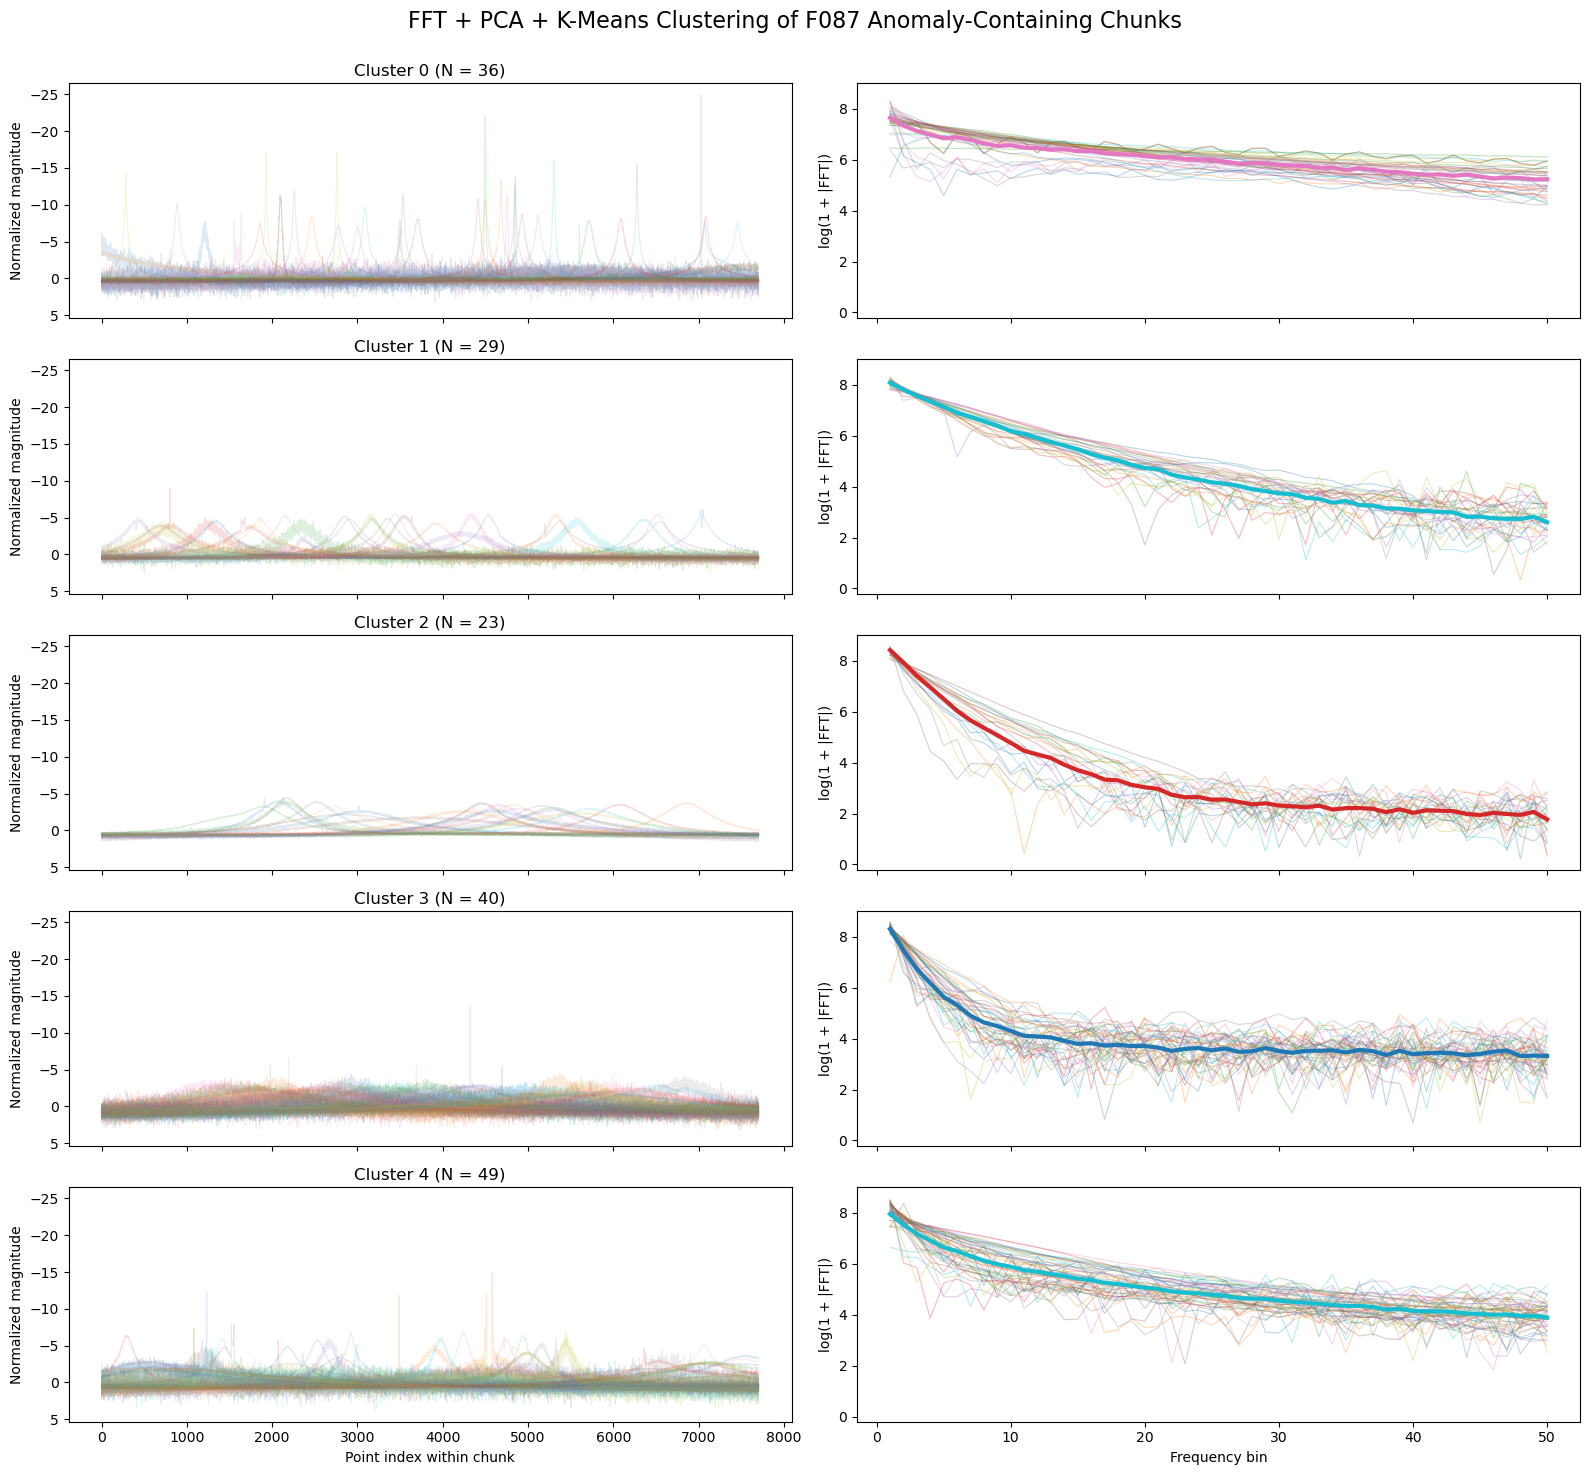

In [7]:
# Left: the clustered chunks in the time domain. Right: their log-magnitude
# spectra (what was actually clustered), with each cluster's centroid
# reconstructed by inverse-transforming its K-Means center out of PCA space.
time_axis = np.arange(CHUNK_LEN)
freq_bins = np.arange(1, N_FREQ + 1)
cluster_centroids = pca.inverse_transform(km.cluster_centers_)

fig, axes = plt.subplots(n_clusters, 2, figsize=(16, 3*n_clusters), sharex="col", sharey="col")

for cluster in range(n_clusters):

    ax_time, ax_freq = axes[cluster]
    members = anomaly_labels == cluster

    if members.any():
        ax_time.plot(time_axis, anomaly_chunks_norm[members].T, alpha=0.15, linewidth=0.8)
        ax_freq.plot(freq_bins, freq_features[members].T, alpha=0.3, linewidth=0.8)

    ax_freq.plot(freq_bins, cluster_centroids[cluster], linewidth=3)

    ax_time.set_ylabel("Normalized magnitude")
    ax_freq.set_ylabel("log(1 + |FFT|)")
    ax_time.set_title(f"Cluster {cluster} (N = {members.sum()})")

axes[0, 0].invert_yaxis()
axes[-1, 0].set_xlabel("Point index within chunk")
axes[-1, 1].set_xlabel("Frequency bin")

fig.suptitle("FFT + PCA + K-Means Clustering of F087 Anomaly-Containing Chunks", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()